## Install Packages

In [ ]:
!pip install pubchempy
!pip install rdkit

## Imports

In [ ]:
import pandas as pd
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit.Chem.Draw import IPythonConsole
from rdkit.Chem.MolStandardize import rdMolStandardize

# From A Messy Supplier File To A Modelling-Ready Table

A colleague has sent you a [CSV](https://en.wikipedia.org/wiki/Comma-separated_values) file of ten compounds pulled out of a bioactivity database, with structures as [SMILES](https://en.wikipedia.org/wiki/Simplified_Molecular_Input_Line_Entry_System) text, a few physicochemical columns and a measured potency.
It looks tidy in a spreadsheet, and it is not: one SMILES is not a molecule at all, two records are salts, one compound appears twice under two different spellings, and two columns are full of gaps.
Today you take that file apart with [pandas](https://pandas.pydata.org/docs/) and [RDKit](https://www.rdkit.org/docs/), decide what each column is for, repair the chemistry, remove the duplicate structure, and deal with the missing values honestly.

## Part 1 - What is Actually in the File

The file below is what arrived.

Each row is one compound: a database identifier (`chembl_id`), a name, a SMILES string, two computed physicochemical properties, a measured aqueous solubility, and a potency reported as [pIC50](https://en.wikipedia.org/wiki/IC50) - the negative logarithm of the concentration that halves the activity of the target, so a larger number means a more potent compound.

| chembl_id | name | smiles | mw | logp | solubility_mg_ml | pIC50 |
|---|---|---|---|---|---|---|
| CHEMBL25 | aspirin | `CC(=O)Oc1ccccc1C(=O)O` | 180.16 | 1.19 | 3.0 | 5.2 |
| CHEMBL113 | caffeine | `Cn1cnc2c1c(=O)n(C)c(=O)n2C` | 194.19 | -0.07 | | 4.8 |
| CHEMBL521 | ibuprofen | `CC(C)Cc1ccc(cc1)C(C)C(=O)O` | 206.28 | | | 4.5 |
| CHEMBL1004 | diphenhydramine HCl | `CN(C)CCOC(c1ccccc1)c1ccccc1.Cl` | 291.82 | | | 7.1 |
| CHEMBL2001 | aspirin (repeat) | `OC(=O)c1ccccc1OC(C)=O` | 180.16 | 1.19 | 2.8 | 5.6 |
| CHEMBL714 | salbutamol sulfate | `CC(C)(C)NCC(O)c1ccc(O)c(CO)c1.OS(=O)(=O)O` | 576.70 | | | 7.4 |
| CHEMBL9999 | junk entry | `C1CC1CC(((` | | | | 6.0 |
| CHEMBL112 | paracetamol | `CC(=O)Nc1ccc(O)cc1` | 151.16 | 0.46 | 14.0 | 5.0 |
| CHEMBL154 | naproxen | `COc1ccc2cc(ccc2c1)C(C)C(=O)O` | 230.26 | 3.18 | | 5.9 |
| CHEMBL118 | celecoxib | `Cc1ccc(cc1)c1cc(nn1c1ccc(cc1)S(N)(=O)=O)C(F)(F)F` | 381.37 | 3.90 | | 7.8 |

*WARNING:* An empty cell in a CSV file becomes a missing value once [pandas reads it](https://pandas.pydata.org/pandas-docs/version/2.3/reference/api/pandas.read_csv.html), and a nonsense SMILES becomes an ordinary string that pandas is perfectly happy with.

Part of this warning is, that we must *always* make sure to clean our data, before we even work with it.


### The File
The contents from the table above is stored in a file `library.csv` by the following code:

In [ ]:
csv_text = """chembl_id,name,smiles,mw,logp,solubility_mg_ml,pIC50
CHEMBL25,aspirin,CC(=O)Oc1ccccc1C(=O)O,180.16,1.19,3.0,5.2
CHEMBL113,caffeine,Cn1cnc2c1c(=O)n(C)c(=O)n2C,194.19,-0.07,,4.8
CHEMBL521,ibuprofen,CC(C)Cc1ccc(cc1)C(C)C(=O)O,206.28,,,4.5
CHEMBL1004,diphenhydramine HCl,CN(C)CCOC(c1ccccc1)c1ccccc1.Cl,291.82,,,7.1
CHEMBL2001,aspirin (repeat),OC(=O)c1ccccc1OC(C)=O,180.16,1.19,2.8,5.6
CHEMBL714,salbutamol sulfate,CC(C)(C)NCC(O)c1ccc(O)c(CO)c1.OS(=O)(=O)O,576.70,,,7.4
CHEMBL9999,junk entry,C1CC1CC(((,,,,6.0
CHEMBL112,paracetamol,CC(=O)Nc1ccc(O)cc1,151.16,0.46,14.0,5.0
CHEMBL154,naproxen,COc1ccc2cc(ccc2c1)C(C)C(=O)O,230.26,3.18,,5.9
CHEMBL118,celecoxib,Cc1ccc(cc1)c1cc(nn1c1ccc(cc1)S(N)(=O)=O)C(F)(F)F,381.37,3.90,,7.8
"""
with open("library.csv", "w") as fh:
    fh.write(csv_text)

#### Questions
1. Complete the line below so `library.csv` is read into a DataFrame called `records`.
2. We print the `records` but use the `records.heads()` instead of just `record`. What is the effect? and is data missing? *hint:* you can [read the documentation](https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.DataFrame.head.html) to get an idea.


In [ ]:
records = pd.read_csv("library.csv")  #! read the file written above
print(records.head())

    chembl_id                 name                          smiles      mw  \
0    CHEMBL25              aspirin           CC(=O)Oc1ccccc1C(=O)O  180.16   
1   CHEMBL113             caffeine      Cn1cnc2c1c(=O)n(C)c(=O)n2C  194.19   
2   CHEMBL521            ibuprofen      CC(C)Cc1ccc(cc1)C(C)C(=O)O  206.28   
3  CHEMBL1004  diphenhydramine HCl  CN(C)CCOC(c1ccccc1)c1ccccc1.Cl  291.82   
4  CHEMBL2001     aspirin (repeat)           OC(=O)c1ccccc1OC(C)=O  180.16   

   logp  solubility_mg_ml  pIC50  
0  1.19               3.0    5.2  
1 -0.07               NaN    4.8  
2   NaN               NaN    4.5  
3   NaN               NaN    7.1  
4  1.19               2.8    5.6  


#### Answers

  2. It only prints the first 5 rows of the data.


### Identifiers, Features, and Endpoints
Every column in a dataset like this plays one of three roles.
An **identifier** names the row and is never used as an input to a model.
A **feature** is a property you would feed into a calculation or a model.
An **endpoint** is the measured biological result you want to explain or predict.

From a Data Science perspective, these are three core ideas you need to be able to work with.

#### Questions

3. Name the **identifier** columns, **feature** columns and **endpoint** columns in the data we just loaded in.
4. `solubility_mg_ml` was measured in a laboratory, while `mw` and `logp` were computed from the structure. Does that difference change which of the three roles they play?


In [ ]:
print("identifiers:", ["chembl_id", "name", "smiles"])  #! the columns that only name the compound
print("features:", ["mw", "logp", "solubility_mg_ml"])  #! the columns describing the compound
print("endpoint:", "pIC50")  #! the measured biological outcome

identifiers: ['chembl_id', 'name', 'smiles']
features: ['mw', 'logp', 'solubility_mg_ml']
endpoint: pIC50


#### Answers

  4. No. The role is decided by how the column is used, not by where the number came from.

All three describe the compound and could go in as inputs, so all three are features here.
It matters for a different reason: a computed value exists for every valid structure, while a measured one exists only where somebody ran the assay, which is exactly why `solubility_mg_ml` is the emptiest column in the file.


### The SMILES Column
The `smiles` column looks like chemistry, but at this point it is text and nothing else.
Python can tell you how many characters are in `CC(=O)Oc1ccccc1C(=O)O`, but it cannot tell you how many carbon atoms are in aspirin until [`Chem.MolFromSmiles`](https://www.rdkit.org/docs/source/rdkit.Chem.rdmolfiles.html) has read the string and built the atoms and bonds.

This parsing step is crucial because it is also the only validity check the file will ever get in terms of valid chemistry.

#### Questions

5. Aspirin is $\mathrm{C_9H_8O_4}$, so it has 13 heavy atoms. Predict what `len(smiles_text)` prints, and why it is not 13.
6. Complete the two marked lines so the block parses that same string and prints its heavy-atom count.
7. The last line is just the variable name with no `print`. What appears?


characters in the string: 21
heavy atoms after parsing: 13


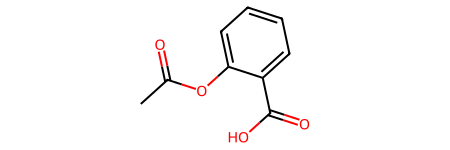

In [ ]:
smiles_text = records["smiles"].iloc[0]
print("characters in the string:", len(smiles_text))
mol = Chem.MolFromSmiles(smiles_text)  #! turn the text into a molecule
print("heavy atoms after parsing:", mol.GetNumAtoms())  #! now chemistry is possible
mol

#### Answers

5. It prints 21, the number of characters in the string, including brackets, digits and bond symbols.
Character count and atom count have nothing to do with each other.
6. A drawing of aspirin appears, because importing `IPythonConsole` registers RDKit's drawing hook for a molecule written on its own line.
`print(mol)` instead asks for the text form of the object and gives you `<rdkit.Chem.rdchem.Mol object at 0x...>`, which tells you nothing.


## Part 2 - Cleaning the Data Set

---

For this part, having worked through videos [1.6](https://youtu.be/0MIv6ibqKso) and [2.4](https://youtu.be/NSQv0xdhhHs) at least will make this a lot easier.

---

Cleaning a chemical table happens in a fixed order:
  1. First parse every SMILES and drop what fails, because every later step needs a molecule object.
  2. Then strip salts down to the active organic species.
  3. Only then canonicalise and look for duplicates.

Step 1 is dangerous precisely because it is quiet: `Chem.MolFromSmiles` returns `None` for a string it cannot read instead of raising an error, so a broken record survives in your table until something else breaks much later.

#### Questions

1. Add a `mol` column to `records` by parsing every SMILES with a list comprehension.
2. Write the loop that walks `name`, `smiles` and `mol` together with `zip` and prints a warning for every record whose molecule is `None`.
3. Comment on the result.

In [ ]:
records["mol"] = [Chem.MolFromSmiles(s) for s in records["smiles"]]  #! one Mol per row, or None

# now we loop through each row of the three important columns and only print if something went wrong.
for name, smiles, mol in zip(records["name"], records["smiles"], records["mol"]):  #! report every record that failed to parse
    if mol is None:  #!
        print("invalid SMILES for", name, ":", smiles)  #!

invalid SMILES for junk entry : C1CC1CC(((


[10:07:49] SMILES Parse Error: syntax error while parsing: C1CC1CC(((
[10:07:49] SMILES Parse Error: check for mistakes around position 9:
[10:07:49] C1CC1CC(((
[10:07:49] ~~~~~~~~^
[10:07:49] SMILES Parse Error: Failed parsing SMILES 'C1CC1CC(((' for input: 'C1CC1CC((('


#### Answers
3. One record failed, and RDKit also printed its own warning about the unclosed parentheses in `C1CC1CC(((`.

Note also what did *not* happen: pandas can happily store `None` in the database.
If we do not remove it or ignore it, all later calculations will fail, so we better clean it up right away.

#### Questions
We will now make a clean dataframe without bad molecules and call it `clean`.

  4. Predict how many rows `clean` will have based on the calculations and data available to you *above* here. Do not run the code just yet.

One way we filter code is to mark rows as *something we want to include* or *something we want to exclude*.
We have previously done this with code like `records["mw"] > 250.0` for example.
Let's dive a little into what actually happens.

  5. Insert the code above and comment on the result.


In [ ]:
records["mw"] > 250.0

,mw
0,False
1,False
2,False
3,True
4,False
5,True
6,False
7,False
8,False
9,True


#### Answers
  4. 10 rows. One less than the number fo rows in the original table.
  5. It prints a new set of columns with either `True` of the condition is fulfilled, or `False` if the condition is not fulfilled.

Using the above as a filter was typically done using the code presented below:

In [ ]:
mass_filter = records["mw"] > 250
records[mass_filter]

,chembl_id,name,smiles,mw,logp,solubility_mg_ml,pIC50,mol
3,CHEMBL1004,diphenhydramine HCl,CN(C)CCOC(c1ccccc1)c1ccccc1.Cl,291.82,NaN,NaN,7.1,<rdkit.Chem.rdchem.Mol object at 0x7ac25d1440b0>
5,CHEMBL714,salbutamol sulfate,CC(C)(C)NCC(O)c1ccc(O)c(CO)c1.OS(=O)(=O)O,576.70,NaN,NaN,7.4,<rdkit.Chem.rdchem.Mol object at 0x7ac25d146810>
9,CHEMBL118,celecoxib,Cc1ccc(cc1)c1cc(nn1c1ccc(cc1)S(N)(=O)=O)C(F)(F)F,381.37,3.9,NaN,7.8,<rdkit.Chem.rdchem.Mol object at 0x7ac25d1478b0>


#### Questions
  6. Explain what happend to your data

#### Answers
  6. All rows with `False` are ignored and not printed.

### Ensuring That the Bogus Molecule does Not Survive
Let us make our own filter but for whether a molecule was valid or not.

#### Questions
  7. Construct a list `[]` named `clean_filter` with either `True` or `False` depending on whether a given row has a molecule that valid or not. *hint:* A valid molecule would mean that `True` is put into the list.

In [ ]:
clean_filter = []
for molecule in records["mol"]:
    if molecule is None:
        clean_filter.append(False)
    else:
        clean_filter.append(True)
clean_filter

[True, True, True, True, True, True, False, True, True, True]

#### Questions
  8. Apply the new `clean_filter` to records and store in a new `clean_records` dataframe. Comment on the results.

In [ ]:
clean_records = records[clean_filter].copy()
clean_records

,chembl_id,name,smiles,mw,logp,solubility_mg_ml,pIC50,mol
0,CHEMBL25,aspirin,CC(=O)Oc1ccccc1C(=O)O,180.16,1.19,3.0,5.2,<rdkit.Chem.rdchem.Mol object at 0x7ac25fafc120>
1,CHEMBL113,caffeine,Cn1cnc2c1c(=O)n(C)c(=O)n2C,194.19,-0.07,NaN,4.8,<rdkit.Chem.rdchem.Mol object at 0x7ac25d147c30>
2,CHEMBL521,ibuprofen,CC(C)Cc1ccc(cc1)C(C)C(=O)O,206.28,NaN,NaN,4.5,<rdkit.Chem.rdchem.Mol object at 0x7ac25d147220>
3,CHEMBL1004,diphenhydramine HCl,CN(C)CCOC(c1ccccc1)c1ccccc1.Cl,291.82,NaN,NaN,7.1,<rdkit.Chem.rdchem.Mol object at 0x7ac25d1440b0>
4,CHEMBL2001,aspirin (repeat),OC(=O)c1ccccc1OC(C)=O,180.16,1.19,2.8,5.6,<rdkit.Chem.rdchem.Mol object at 0x7ac25d146ff0>
5,CHEMBL714,salbutamol sulfate,CC(C)(C)NCC(O)c1ccc(O)c(CO)c1.OS(=O)(=O)O,576.70,NaN,NaN,7.4,<rdkit.Chem.rdchem.Mol object at 0x7ac25d146810>
7,CHEMBL112,paracetamol,CC(=O)Nc1ccc(O)cc1,151.16,0.46,14.0,5.0,<rdkit.Chem.rdchem.Mol object at 0x7ac25d147a70>
8,CHEMBL154,naproxen,COc1ccc2cc(ccc2c1)C(C)C(=O)O,230.26,3.18,NaN,5.9,<rdkit.Chem.rdchem.Mol object at 0x7ac25d147920>
9,CHEMBL118,celecoxib,Cc1ccc(cc1)c1cc(nn1c1ccc(cc1)S(N)(=O)=O)C(F)(F)F,381.37,3.90,NaN,7.8,<rdkit.Chem.rdchem.Mol object at 0x7ac25d1478b0>


#### Answers
  8. We now have a clean data frame without any molecules we at least cannot use later.

### Displaying the Good Molecules
Use [the solutions from the old exercise](https://colab.research.google.com/drive/1UesS14AkJJghhXw1tDb1Bpj2Z0mfCk-r#scrollTo=b569c00c) to generate a grid of all the good molecules.

#### Questions
  9. Use the column `mol` in `clean_records` from above, go generate a grid of molecules. Similarly to last time, the molecule names should be displayed under each.

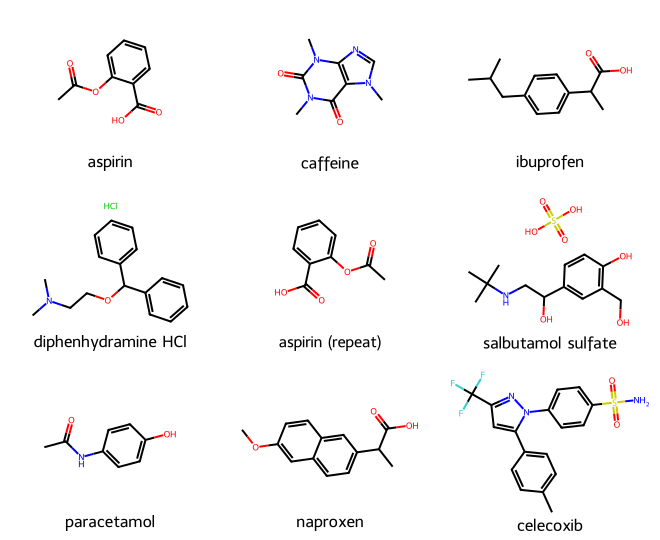

In [ ]:
mols = list(clean_records["mol"].values)
names = list(clean_records["name"].values)
grid = Draw.MolsToGridImage(mols, molsPerRow=3, subImgSize=(220, 180), legends=names)  #! tile the ten molecules with their names
grid

#### Questions
  10. Are there molecules that trouble you?

#### Answers
  10. There are two molecules that are repeated (aspirin). And there are molecules that have salts.

### Dealing with Salts
A central cleaning task for your data is to ensure that the data is actually representing the molecules you want.
In the figure above, you clearly observe that two molecules are salts.

In a SMILES string, a dot (`.`) separates [disconnected components](https://www.daylight.com/dayhtml/doc/theory/theory.smiles.html#RTFToC20), so `CN(C)CCOC(c1ccccc1)c1ccccc1.Cl` is the [diphenhydramine](https://en.wikipedia.org/wiki/Diphenhydramine) cation *and* a chloride atom, stored as one record. The counter-ion contributes to molecular weight, to logP, to every descriptor you *compute* and it is not the species that binds the target, so for modelling we keep the *largest part of the molecule* and discard the rest.

The function `rdMolStandardize.LargestFragmentChooser` from RDKit does this ([video 2.4](https://youtu.be/NSQv0xdhhHs)).
You build one chooser object and call `choose(mol)` on each molecule, getting the biggest connected fragment back.

#### Questions
Diphenhydramine hydrochloride is stored with the chloride attached as entry number 4 in the `clean_records` dataframe.

  11. How many atoms should there be less after we have selected only the largest fragment?
  12. Fix the code below.


In [ ]:
chooser = rdMolStandardize.LargestFragmentChooser()
salt_mol = clean_records["mol"].iloc[3]  #! 4th item is number 3 - remember we count from 0
parent_mol = chooser.choose(salt_mol)  #! keep the biggest connected fragment

print("with salt:", salt_mol.GetNumAtoms(), "heavy atoms")
print("parent:", parent_mol.GetNumAtoms(), "heavy atoms")

with salt: 20 heavy atoms
parent: 19 heavy atoms


[10:07:49] Running LargestFragmentChooser
[10:07:49] Fragment: CN(C)CCOC(c1ccccc1)c1ccccc1
[10:07:49] New largest fragment: CN(C)CCOC(c1ccccc1)c1ccccc1 (40)
[10:07:49] Fragment: Cl


#### Answers

11. By one.

Chloride is a single heavy atom, so 20 becomes 19 the hydrogen of the hydrochloride was implicit all along and never counted.
Salbutamol sulfate loses five, because a sulfate brings one sulfur and four oxygens.


### Canonical SMILES of the parent fragment
So far, we have used `Chem.MolFromSmiles` to convert a SMILES string, into a molecule.
There is a function that we will use now `Chem.MolToSmiles` that turns a molecule back into a SMILES string.
Calling this funcion *always* produces the **canonical** form of a SMILES string, .i.e., RDKit's agreed spelling for a SMILES string.

Our task now is to run every parent fragment through this step of canonicalizing the molecules to give a new column (`canonical_smiles`) in which two records of the same compound are guaranteed to look identical.

#### Questions

  13. Write the loop that takes each molecule in `clean["mol"]`, chooses its largest fragment, and appends the canonical SMILES of that fragment to `parent_smiles`.
  14. Store the finished list as a new column `canonical_smiles` and print `name`, `smiles` and `canonical_smiles` side by side.


In [ ]:
canon_smiles = []
for molecule in clean_records["mol"]:
    parent_molecule = chooser.choose(molecule)  #! strip the salt off each molecule
    canon_smiles.append(Chem.MolToSmiles(parent_molecule))  #!  and store its canonical SMILES

clean_records["canonical_smiles"] = canon_smiles  #! attach the list as a column

[10:07:49] Running LargestFragmentChooser
[10:07:49] Running LargestFragmentChooser
[10:07:49] Running LargestFragmentChooser
[10:07:49] Running LargestFragmentChooser
[10:07:49] Fragment: CN(C)CCOC(c1ccccc1)c1ccccc1
[10:07:49] New largest fragment: CN(C)CCOC(c1ccccc1)c1ccccc1 (40)
[10:07:49] Fragment: Cl
[10:07:49] Running LargestFragmentChooser
[10:07:49] Running LargestFragmentChooser
[10:07:49] Fragment: CC(C)(C)NCC(O)c1ccc(O)c(CO)c1
[10:07:49] New largest fragment: CC(C)(C)NCC(O)c1ccc(O)c(CO)c1 (38)
[10:07:49] Fragment: O=S(=O)(O)O
[10:07:49] Running LargestFragmentChooser
[10:07:49] Running LargestFragmentChooser
[10:07:49] Running LargestFragmentChooser


Let us now compare the SMILES strings with each other.
#### Questions
  15. Create a list of column names to keep by extending the list below.
  16. Comment on the rows with aspirin, for example.

In [ ]:
columns_to_show = ["name", "smiles", "canonical_smiles"]
clean_records[columns_to_show]

,name,smiles,canonical_smiles
0,aspirin,CC(=O)Oc1ccccc1C(=O)O,CC(=O)Oc1ccccc1C(=O)O
1,caffeine,Cn1cnc2c1c(=O)n(C)c(=O)n2C,Cn1c(=O)c2c(ncn2C)n(C)c1=O
2,ibuprofen,CC(C)Cc1ccc(cc1)C(C)C(=O)O,CC(C)Cc1ccc(C(C)C(=O)O)cc1
3,diphenhydramine HCl,CN(C)CCOC(c1ccccc1)c1ccccc1.Cl,CN(C)CCOC(c1ccccc1)c1ccccc1
4,aspirin (repeat),OC(=O)c1ccccc1OC(C)=O,CC(=O)Oc1ccccc1C(=O)O
5,salbutamol sulfate,CC(C)(C)NCC(O)c1ccc(O)c(CO)c1.OS(=O)(=O)O,CC(C)(C)NCC(O)c1ccc(O)c(CO)c1
7,paracetamol,CC(=O)Nc1ccc(O)cc1,CC(=O)Nc1ccc(O)cc1
8,naproxen,COc1ccc2cc(ccc2c1)C(C)C(=O)O,COc1ccc2cc(C(C)C(=O)O)ccc2c1
9,celecoxib,Cc1ccc(cc1)c1cc(nn1c1ccc(cc1)S(N)(=O)=O)C(F)(F)F,Cc1ccc(-c2cc(C(F)(F)F)nn2-c2ccc(S(N)(=O)=O)cc2...


#### Answers
  16. Look at the two aspirin rows. The input strings `CC(=O)Oc1ccccc1C(=O)O` and `OC(=O)c1ccccc1OC(C)=O` share hardly a character, and the canonical strings are now identical letter for letter.

Since having two compounds being the same, it could potentially cause us problems.
Look in the entire table (`clean_records`) and see if any of the numerical values could mean we are in trouble.

In [ ]:
clean_records

,chembl_id,name,smiles,mw,logp,solubility_mg_ml,pIC50,mol,canonical_smiles
0,CHEMBL25,aspirin,CC(=O)Oc1ccccc1C(=O)O,180.16,1.19,3.0,5.2,<rdkit.Chem.rdchem.Mol object at 0x7ac25fafc120>,CC(=O)Oc1ccccc1C(=O)O
1,CHEMBL113,caffeine,Cn1cnc2c1c(=O)n(C)c(=O)n2C,194.19,-0.07,NaN,4.8,<rdkit.Chem.rdchem.Mol object at 0x7ac25d147c30>,Cn1c(=O)c2c(ncn2C)n(C)c1=O
2,CHEMBL521,ibuprofen,CC(C)Cc1ccc(cc1)C(C)C(=O)O,206.28,NaN,NaN,4.5,<rdkit.Chem.rdchem.Mol object at 0x7ac25d147220>,CC(C)Cc1ccc(C(C)C(=O)O)cc1
3,CHEMBL1004,diphenhydramine HCl,CN(C)CCOC(c1ccccc1)c1ccccc1.Cl,291.82,NaN,NaN,7.1,<rdkit.Chem.rdchem.Mol object at 0x7ac25d1440b0>,CN(C)CCOC(c1ccccc1)c1ccccc1
4,CHEMBL2001,aspirin (repeat),OC(=O)c1ccccc1OC(C)=O,180.16,1.19,2.8,5.6,<rdkit.Chem.rdchem.Mol object at 0x7ac25d146ff0>,CC(=O)Oc1ccccc1C(=O)O
5,CHEMBL714,salbutamol sulfate,CC(C)(C)NCC(O)c1ccc(O)c(CO)c1.OS(=O)(=O)O,576.70,NaN,NaN,7.4,<rdkit.Chem.rdchem.Mol object at 0x7ac25d146810>,CC(C)(C)NCC(O)c1ccc(O)c(CO)c1
7,CHEMBL112,paracetamol,CC(=O)Nc1ccc(O)cc1,151.16,0.46,14.0,5.0,<rdkit.Chem.rdchem.Mol object at 0x7ac25d147a70>,CC(=O)Nc1ccc(O)cc1
8,CHEMBL154,naproxen,COc1ccc2cc(ccc2c1)C(C)C(=O)O,230.26,3.18,NaN,5.9,<rdkit.Chem.rdchem.Mol object at 0x7ac25d147920>,COc1ccc2cc(C(C)C(=O)O)ccc2c1
9,CHEMBL118,celecoxib,Cc1ccc(cc1)c1cc(nn1c1ccc(cc1)S(N)(=O)=O)C(F)(F)F,381.37,3.90,NaN,7.8,<rdkit.Chem.rdchem.Mol object at 0x7ac25d1478b0>,Cc1ccc(-c2cc(C(F)(F)F)nn2-c2ccc(S(N)(=O)=O)cc2...


## Part 3 - The Duplicate Structure

---
We continue from the last exercise where you did Part 1 and Part 2.
The data we work with is stored in `clean_records`.

---

A duplicate entry is problematic.
It is one structure written twice, usually under two names, often with two different measured values, and comparing the raw text will never find it.

The code below compares the original `smiles` for the two aspirin entries.
#### Questions
  1. Why does it print `False`?

In [ ]:
print("raw comparison:", clean_records["smiles"].iloc[0] == clean_records["smiles"].iloc[4])

#### Questions
  2. Take the code from above and fix it, so it compares the `canonical_smiles` instead. Comment on the result.

### Understanding The Data
---
This content is related to [video 2.4](https://youtu.be/NSQv0xdhhHs).

---
Before we try to fix our data, it can be good to understand the data.
The [`aggregate`](https://pandas.pydata.org/pandas-docs/version/2.2/reference/api/pandas.core.groupby.DataFrameGroupBy.aggregate.html#pandas.core.groupby.DataFrameGroupBy.aggregate) function is used after we have [grouped the data](https://pandas.pydata.org/pandas-docs/version/2.2/reference/groupby.html) by potential duplicates is useful to get a sense of the data.

In the following code, we wish to group by the `canonical_smiles` column and then look at what the combined data looks like when we take the mean value of all data that we included.

In [ ]:
group = clean_records.groupby("canonical_smiles")
df_group = group["pIC50"].agg(["mean", "count"])
df_group

#### Questions
  3. Explain the code above in your own words.
  4. Comment on the data above. Compare with the full `clean_records` that is printed above.
  5. Make a filter so you only present the data where the are actual duplicates in the `df_group` dataframe.

In [ ]:
filter_duplicates = _
df_group[_]

### Removing Duplicates
---
This content uses `list` and `set` data structures that you saw in [video 1.4](https://www.youtube.com/watch?v=KLVQiM47GYY).

---


We must now fix the data.
Typically, we would like to store only *one* value per compound but the `aggregate` function we used above can be quite clumsy to use when updating the data back into the `clean_records` dataframe.

Instead, we will use a more manual approach, but it shows you just how to tackle this problem later on in the course.


We will use a loop over the rows of the `canonical_smiles` column to identify if a molecule has been observed or not.
To do this, we must store the SMILES strings in a `set` called `unique_smiles`.

For each iteration of the loop, we perform the following actions if it is the first time we have seen the SMILES string:
  * store `True` in the list `first_occurence`
  * add the SMILES string to the `unique_smiles`

otherwise, we:
  * store `False` in the list `first_occurence`

#### Questions
  6. Why can the [data structure `set`](https://docs.python.org/3/tutorial/datastructures.html#sets) be used to store the unique SMILES strings?
  7. Complete the code below and observe if there is a value `False` at the position of the second aspirin in the new `fixed_records` dataframe.

In [ ]:
unique_smiles = set()
first_occurence = []

for smiles in clean_records[_]:
    if _ not in unique_smiles:
        unique_smiles.add(_)
        first_occurence.append(_)
    _:
        first_occurence.append(_)

print(first_occurence)

#### Questions
  8. Before executing the code below, explain what will happen in your own words.
  9. Execute the code below and compare the `pIC50` values of the aspirin row(s) with values from our use of `aggregate` above, and the original `clean_records` even further up. Explain what happend to the data.
  10. Comment on the molecular weight of the resulting molecules - are they still valid for all the molecules we work with?

In [ ]:
unique_records = clean_records[first_occurence]
unique_records

## Part 4 - Towards a Final Dataset

---
[Video 2.7](https://www.youtube.com/watch?v=tErfCybJnb8) is relevant for the following.

---
Eight structures, each appearing once, each valid chemistry.
What remains is the emptiness: `logp` was never computed for three of them and `solubility_mg_ml` was measured for only two.
Missing values in a pharmaceutical table are rarely random and could be due to a number of reasons.
A solubility could be absent because (1) the assay was never run or (2) because the compound was too insoluble to measure.


### Making a Relevant Dataset

The `mol` columns was scaffolding for the cleaning we did above and have no place in the finished `dataset`, so the first step is to select the columns worth keeping.

#### Questions
  1. Make a list called `columns` with the content of the column names we wish to keep: `name`, `canonical_smiles`, `mw`, `logp`, `solubility_mg_ml`, `pIC50`.
  1. Make a `dataset` variable based on `unique_records` above keeping only the columns you just named in the `columns` variable.

In [ ]:
columns = [...]
dataset = unique_records[_]
dataset

The value of `NaN` above indicates that there was nothing in the dataset for that particular compound.
A pandas dataframe can get us how many values are missing.
The `isna()` function does exactly that.
#### Question
  3. Comment on the result of the code below

In [ ]:
dataset.isna()

#### Answers
  3. There are `True` where the numbers are NaN and `False` everywhere else.

Getting information per column is often more useful.
For example getting the number of missing data points.
#### Questions
  4. Comment on the output of the code below.

In [ ]:
dataset.isna().sum()

We have previously used the `describe()` function on a dataframe.
#### Question
  5. Execute the code below to get summary statistics with `describe()` and comment on what potential problems there (especially with logP and solubility) could be now that you know that there are `NaN` values in the dataset.

In [ ]:
dataset.describe().round(2)

### Visualizing the Data

In [ ]:
import matplotlib.pyplot as plt

A [scatter plot](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.scatter.html) puts one dot per compound, with one property on each axis, and shows whether the two move together ([video 2.8](https://youtu.be/ADGUR9iOShw)).

Before we make the plot, it is a good idea to think about what the result might be. If it comes out like you did not expect, then you might have found a problem with your data.

For each compound we plot `pIC50` against `logp`.
#### Questions
  7. Do you have any expectation about what the plot will look like? Write a few sentences about what you expect.
  8. Complete the code below to make a nice looking scatter plot (videos include `grid` but that is rarely useful to include).
  9. How much data out of the original is plotted?
  10. Describe what you see and compare with your answer in 7. from abve.

In [ ]:
plt.figure(figsize=(5,5))
plt.scatter(dataset["_"], _["_"])
plt.xlabel("_")
plt.ylabel("_")
plt.title("Potency versus Lipophilicity")
plt.show()

### Filling the Gaps
We have now seen the consequences of the missing data.
We could of course just drop the rows of data if there is `NaN` present.

### Questions
  11. Comment on the resulting code below where we use the [`dropna()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.dropna.html) function on the `dataset` dataframe.

In [ ]:
dataset.dropna()

This is not something we want.
First, we remove the column with very little data to generate a `reduced` dataset by dropping the columns with too many `NaN`s.

#### Questions
  12. Complete the code below to remove only the column more than 5 datapoints. Explain in your own words what the code does. Documentation for

In [ ]:
reduced = dataset.dropna(axis=1, thresh=_)
reduced

We will fix our data by filling the missing data in the `reduced` dataframe of the logP column with either the `mean` or the `median` values of the existing data.
#### Questions
  13. Describe in your own words what the difference between `mean` and `median` is.
  14. Which would be the safer choice?
  15. What could be the problem by using this approach?

Below, code to calculate the mean and the median is given.
The values are stored in two independent variables.

In [ ]:
mean = reduced["logp"].mean()
median = reduced["logp"].median()

We make ready for a `final_dataset` below by copying the `reduced` dataframe.

In [ ]:
final_dataset = reduced.copy()

We are now ready to fill in missing data all at once using the [`fillna()`](https://pandas.pydata.org/docs/reference/api/pandas.DataFrame.fillna.html) function.
It only replaces `NaN` values.
#### Questions
  16. Why could we not use the `fillna` function on the pIC50 data for aspirin?
  17. Use the `fillna()` function to replace the `NaN` values in the logP data with either the mean or the median (depending on your answer to question 14) in the `final_dataset` dataframe.

In [ ]:
final_dataset["logp"] = _[_].fillna(_)
final_dataset

#### Questions
  18. Redo the plot using the new `final_dataset` dataframe and comment on the result.

## Part 5 - Additional Things to do From Here
####
  1. You can use the `to_csv()` function on the `final_dataset` dataframe to store the data back in the .csv format and share with your friends or others.
